In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [107]:
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?

  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  
  print(X.shape, Y.shape)
  
  return X, Y

import random
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182473, 3]) torch.Size([182473])
torch.Size([22827, 3]) torch.Size([22827])
torch.Size([22846, 3]) torch.Size([22846])


In [20]:
torch.cat([emb[:, 0, :], emb[:, 1, :],emb[:, 2, :]], 1).shape

torch.Size([22, 6])

In [22]:
torch.cat(torch.unbind(emb, 1), 1).shape #unbind 1st index of emb (ie does whats in the above cell)

torch.Size([22, 6])

In [24]:
a = torch.arange(18)

a.view(3, 3, 2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [33]:
counts = logits.exp()

In [36]:
prob = counts / counts.sum(1, keepdim=True)
prob.shape

torch.Size([22, 27])

In [40]:
loss = -prob[torch.arange(22), Y].log().mean()
loss

tensor(18.6352)

In [56]:
torch.randint(0, X.shape[0], (32,))

tensor([210230, 137342, 215240, 203888, 171638, 137787,  47317, 223172,  17594,
        167792, 105612,  82790,  13179,  68853, 142060,  20493,  92374, 104848,
         29157, 199541, 174814,  87629, 211227, 201684, 138681,  38562, 123292,
         59633, 147501, 106686,  27647,  83657])

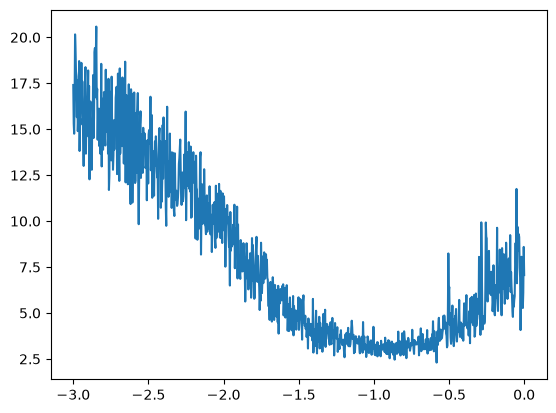

In [101]:
plt.plot(lri, lossi)

In [138]:
C = torch.randn((27, 10))
W1 = torch.randn((30, 200))
b1 = torch.randn(200)
W2 = torch.randn((200, 27))
b2 = torch.randn(27)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [137]:
sum(p.nelement() for p in parameters)

11897

In [139]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [140]:
lri = []
lossi = []
stepi = []

In [143]:
for i in range(50000):
    
    #batch
    ix = torch.randint(0, Xtr.shape[0], (32,))

    #forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100) pytorch infers if -1 is given
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    #update
    lr = 0.1 # lrs[i]
    
    for p in parameters:
        p.data += -lr * p.grad
        
    #track
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

In [128]:
loss

tensor(2.9017, grad_fn=<NllLossBackward0>)

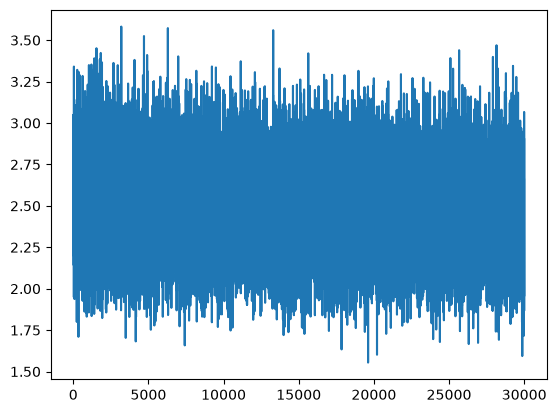

In [129]:
plt.plot(stepi, lossi)

In [ ]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100) pytorch infers if -1 is given
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)

In [133]:
loss

tensor(2.4445, grad_fn=<NllLossBackward0>)

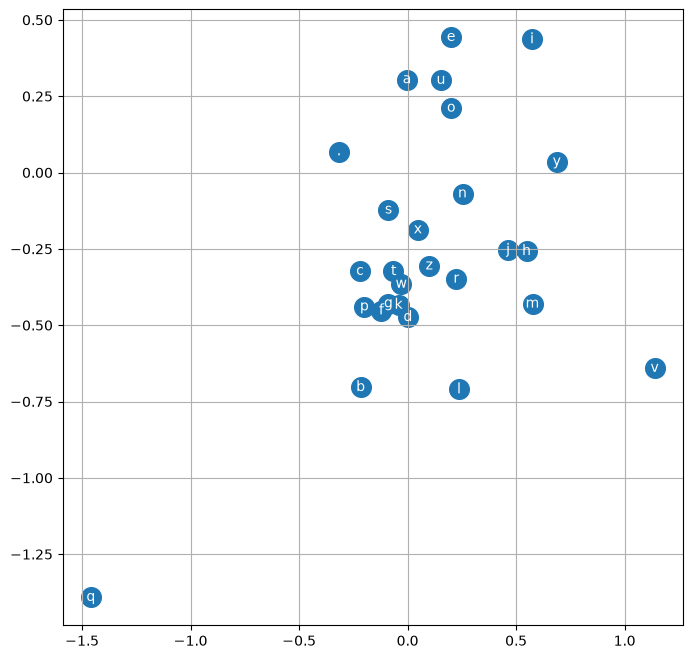

In [135]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)

for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")

plt.grid('minor')

## Knobs

- [ ] Neurons in Hidden Layer
- [ ] Dimensionality of Embedding
- [ ] Character Lookup Table
- [ ] Learning Rate
- [ ] Batch Size
- [ ] Time Running